In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:

df = pd.read_csv(r"/home/sarthakredasani/Documents/CDAC_ML/Cases/Cases/Wisconsin/BreastCancer.csv", index_col=0)
X, y = df.drop('Class', axis=1), df['Class']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=25, test_size=0.3)

In [4]:
dtc = DecisionTreeClassifier(random_state=25)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9285714285714286


In [5]:
depths = [2,3,4,5,6, None]
scores = []
for d in depths:
    dtc = DecisionTreeClassifier(random_state=25, max_depth=d)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    scores.append([d, accuracy_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores, columns = ['Depth','score'])
df_scores.sort_values('score', ascending=False)

,Depth,score
1,3.0,0.952381
2,4.0,0.947619
3,5.0,0.942857
4,6.0,0.933333
5,NaN,0.928571
0,2.0,0.914286


In [6]:
min_samples = [2, 10, 20, 50, 75]
scores = []
for m in min_samples:
    dtc = DecisionTreeClassifier(random_state=25, min_samples_split=m)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    scores.append([m, accuracy_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores, columns = ['Min Samples Split','score'])
df_scores.sort_values('score', ascending=False)

,Min Samples Split,score
2,20,0.961905
1,10,0.957143
0,2,0.928571
3,50,0.919048
4,75,0.919048


In [7]:
min_leaf = [1, 10, 20, 50, 75]
scores = []
for f in min_leaf:
    dtc = DecisionTreeClassifier(random_state=25, min_samples_leaf=f)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    scores.append([f, accuracy_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores, columns = ['Min Samples Leaf','score'])
df_scores.sort_values('score', ascending=False)

,Min Samples Leaf,score
1,10,0.942857
0,1,0.928571
2,20,0.904762
3,50,0.904762
4,75,0.904762


In [8]:
# Hyper-Parameter Tuning

In [13]:
depths = [2,3,4,5,6, None]
min_samples = [2, 10, 20, 50, 75]
min_leaf = [1, 10, 20, 50, 75]
scores = []
for d in depths:
    for m in min_samples:
        for f in min_leaf:
                dtc = DecisionTreeClassifier(random_state=25, 
                        min_samples_leaf=f, max_depth=d, min_samples_split=m)
                dtc.fit(X_train, y_train)
                y_pred = dtc.predict(X_test)
                scores.append([d,m,f, accuracy_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores, columns = ['Depth','Min Samples Split','Min Samples Leaf','score'])
df_scores.sort_values('score', ascending=False).iloc[0]

Depth                      NaN
Min Samples Split    20.000000
Min Samples Leaf      1.000000
score                 0.961905
Name: 135, dtype: float64

In [14]:
best_tree = DecisionTreeClassifier(random_state=25, 
                                   min_samples_leaf=1, max_depth=None, min_samples_split=20)
best_tree.fit(X,y)

DecisionTreeClassifier(min_samples_split=20, random_state=25)

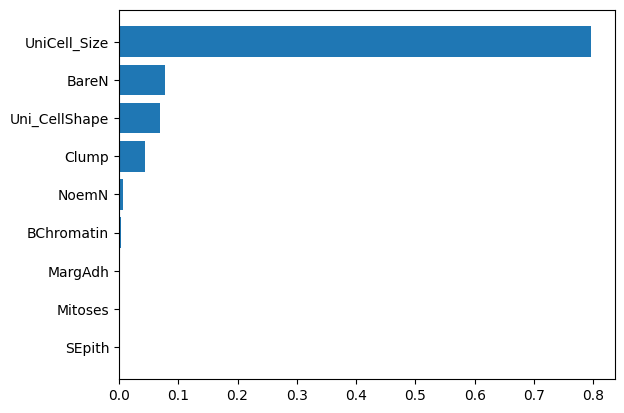

In [15]:
df_imp = pd.DataFrame({'Feature':list(X.columns),
                       'Importance':list(best_tree.feature_importances_)})
df_imp = df_imp.sort_values('Importance')
plt.barh(df_imp['Feature'], df_imp['Importance'])
plt.show()

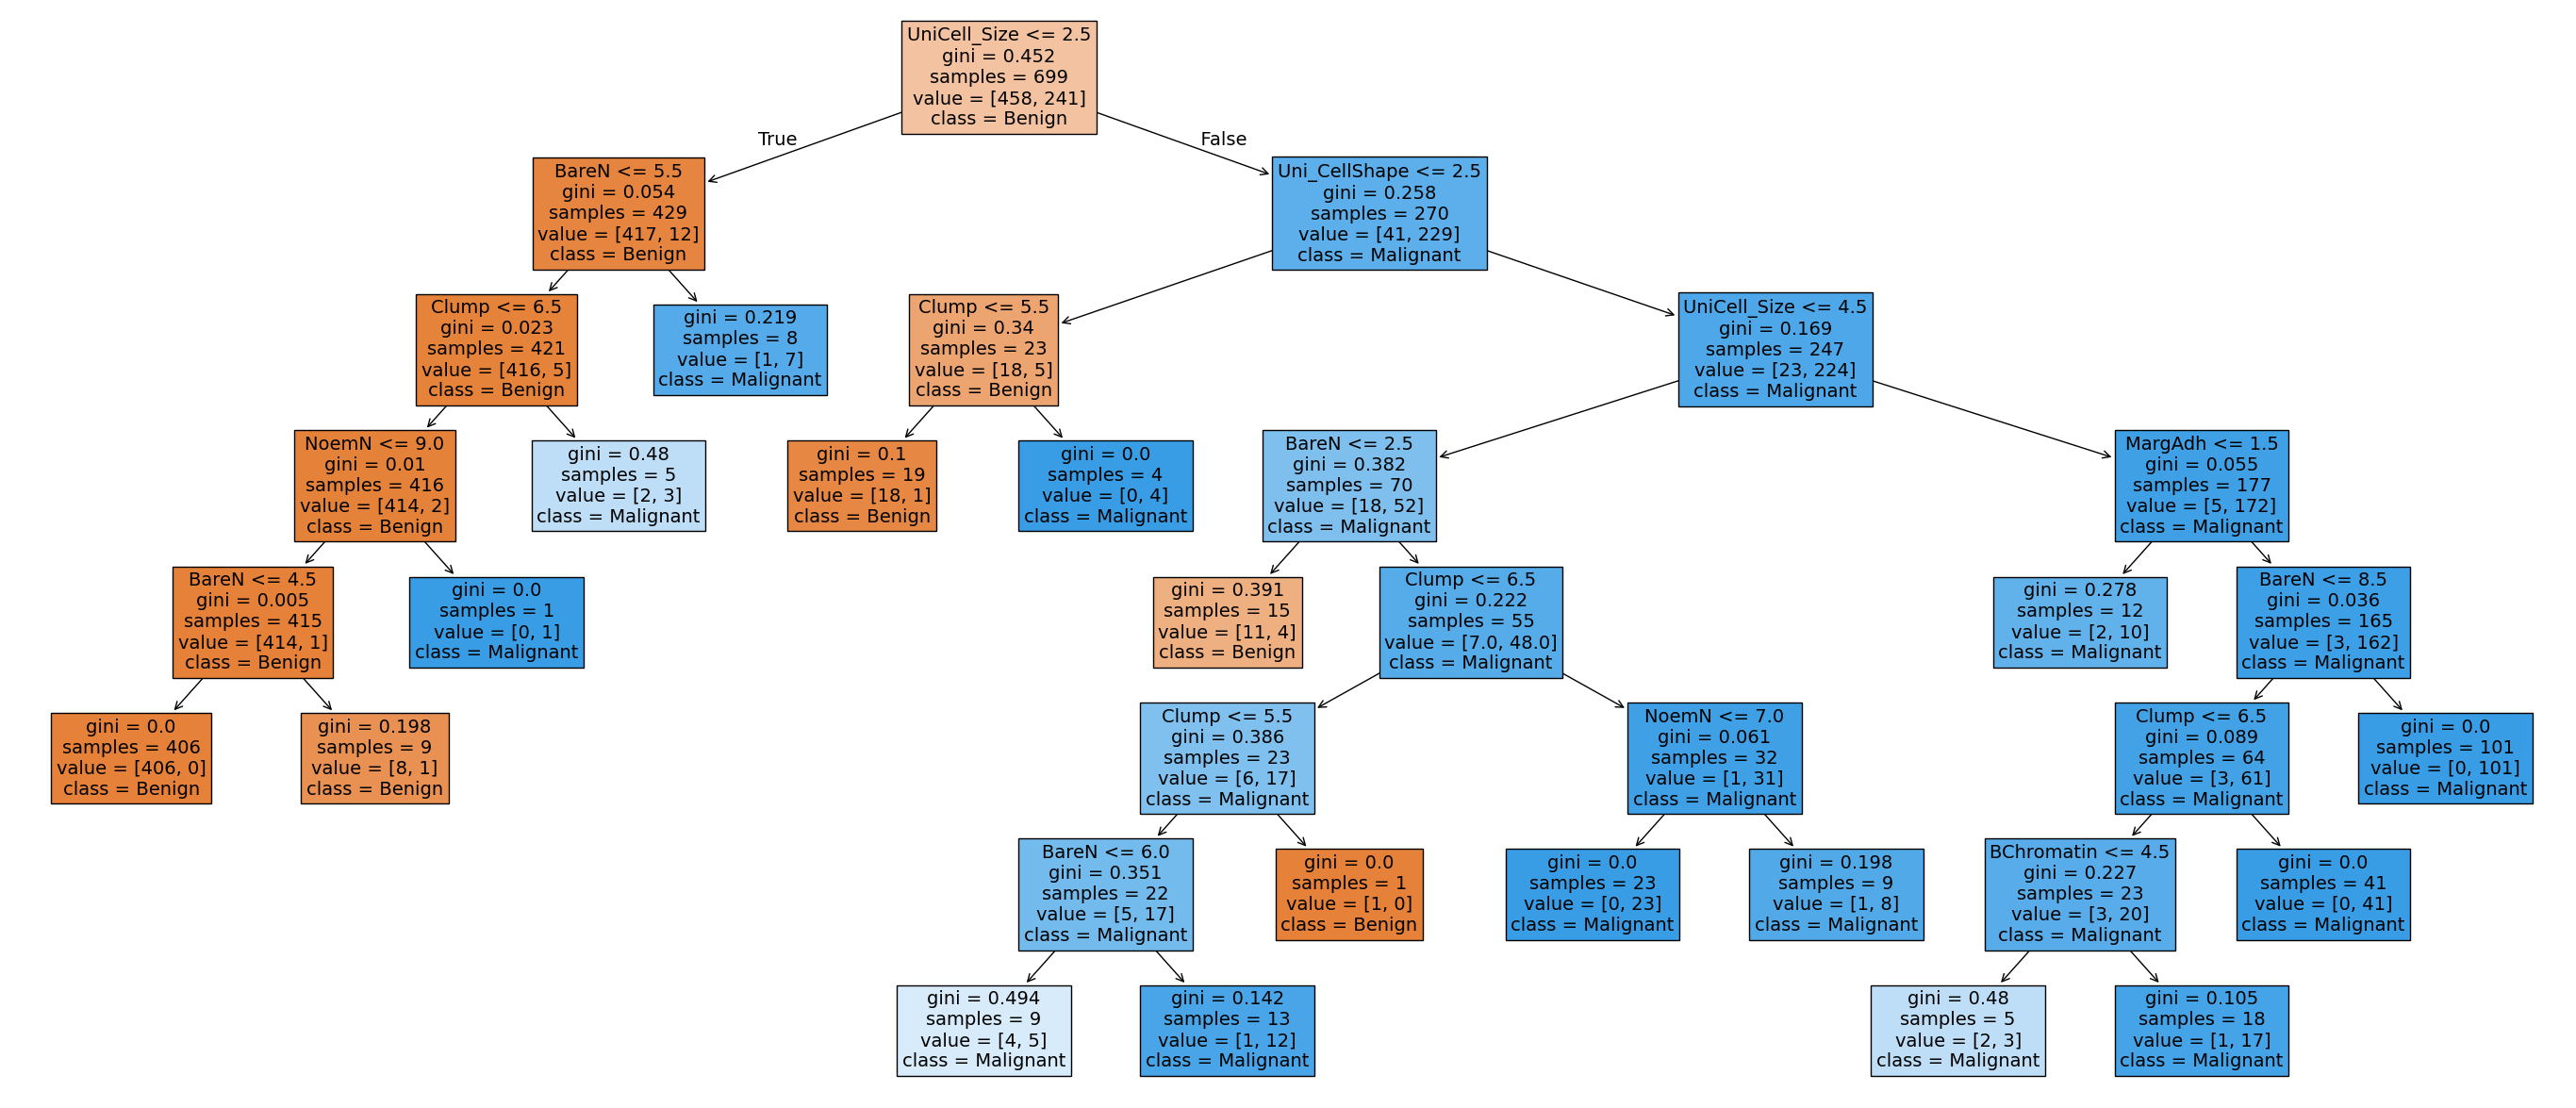

In [16]:
plt.figure(figsize=(35,15))
plot_tree(best_tree,feature_names=list(X.columns), 
          class_names=['Benign','Malignant'], filled=True,fontsize=14)
plt.show() 

In [17]:
X.columns

Index(['Clump', 'UniCell_Size', 'Uni_CellShape', 'MargAdh', 'SEpith', 'BareN',
       'BChromatin', 'NoemN', 'Mitoses'],
      dtype='object')

In [18]:
best_tree.feature_importances_

array([0.04359276, 0.79667155, 0.06984243, 0.00172209, 0.        ,
       0.07743997, 0.00324156, 0.00748964, 0.        ])